In [1]:
from google.colab import files

uploaded = files.upload()

Saving Nhatkychung.csv to Nhatkychung.csv


In [3]:
import pandas as pd

df = pd.read_csv('Nhatkychung.csv')

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report


In [5]:
df = pd.read_csv('Nhatkychung.csv')

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [6]:
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 11 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   step            1048575 non-null  int64  
 1   type            1048575 non-null  object 
 2   amount          1048575 non-null  float64
 3   nameOrig        1048575 non-null  object 
 4   oldbalanceOrg   1048575 non-null  float64
 5   newbalanceOrig  1048575 non-null  float64
 6   nameDest        1048575 non-null  object 
 7   oldbalanceDest  1048575 non-null  float64
 8   newbalanceDest  1048575 non-null  float64
 9   isFraud         1048575 non-null  int64  
 10  isFlaggedFraud  1048575 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 88.0+ MB
None

Missing values:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud    

In [7]:
model_df = df.copy()

# Encode cột type
if 'type' in model_df.columns:
    le = LabelEncoder()
    model_df['type'] = le.fit_transform(model_df['type'])

# Xóa cột text
remove_cols = []

for col in ['nameOrig', 'nameDest']:
    if col in model_df.columns:
        remove_cols.append(col)

model_df = model_df.drop(columns=remove_cols)

model_df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,3,9839.64,170136.0,160296.36,0.0,0.0,0,0
1,1,3,1864.28,21249.0,19384.72,0.0,0.0,0,0
2,1,4,181.00,181.0,0.00,0.0,0.0,1,0
3,1,1,181.00,181.0,0.00,21182.0,0.0,1,0
4,1,3,11668.14,41554.0,29885.86,0.0,0.0,0,0


In [8]:
if 'isFraud' in model_df.columns:
    y_true = model_df['isFraud']
    X = model_df.drop(columns=['isFraud'])
else:
    y_true = None
    X = model_df

print(X.head())

   step  type    amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
0     1     3   9839.64       170136.0       160296.36             0.0   
1     1     3   1864.28        21249.0        19384.72             0.0   
2     1     4    181.00          181.0            0.00             0.0   
3     1     1    181.00          181.0            0.00         21182.0   
4     1     3  11668.14        41554.0        29885.86             0.0   

   newbalanceDest  isFlaggedFraud  
0             0.0               0  
1             0.0               0  
2             0.0               0  
3             0.0               0  
4             0.0               0  


In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-1.6620219   0.9565757  -0.56173807 -0.23685497 -0.24383202 -0.42588334
  -0.46106169  0.        ]
 [-1.6620219   0.9565757  -0.59184049 -0.28695576 -0.29067345 -0.42588334
  -0.46106169  0.        ]
 [-1.6620219   1.70006662 -0.59819391 -0.29404519 -0.29711726 -0.42588334
  -0.46106169  0.        ]
 [-1.6620219  -0.53040613 -0.59819391 -0.29404519 -0.29711726 -0.41666087
  -0.46106169  0.        ]
 [-1.6620219   0.9565757  -0.55483653 -0.28012309 -0.28718269 -0.42588334
  -0.46106169  0.        ]]


In [10]:
model = IsolationForest(
    n_estimators=100,
    contamination=0.02,
    random_state=42
)

model.fit(X_scaled)

print("Huấn luyện hoàn tất")

Huấn luyện hoàn tất


In [11]:
pred = model.predict(X_scaled)

# đổi:
# -1 -> 1 (bất thường)
# 1 -> 0 (bình thường)

model_df['anomaly'] = pd.Series(pred).map({
    1: 0,
    -1: 1
})

print(model_df['anomaly'].value_counts())

anomaly
0    1027603
1      20972
Name: count, dtype: int64


In [12]:
anomaly_df = model_df[
    model_df['anomaly'] == 1
]

anomaly_df.head(20)

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,anomaly
89,1,4,1429051.47,0.00,0.00,2041543.62,19200000.0,0,0,1
94,1,4,1724887.05,0.00,0.00,3470595.10,19200000.0,0,0,1
358,1,4,1538200.39,0.00,0.00,6977445.38,19200000.0,0,0,1
359,1,4,2421578.09,0.00,0.00,8515645.77,19200000.0,0,0,1
362,1,4,1457213.54,0.00,0.00,10900000.00,19200000.0,0,0,1
375,1,4,2545478.01,0.00,0.00,12400000.00,19200000.0,0,0,1
376,1,4,2061082.82,0.00,0.00,14900000.00,19200000.0,0,0,1
432,1,0,349505.89,7330235.59,7679741.48,17000000.00,19200000.0,0,0,1
463,1,0,222711.47,2419068.96,2641780.43,16700000.00,19200000.0,0,0,1
557,1,1,227478.01,25743.78,0.00,16400000.00,19200000.0,0,0,1


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


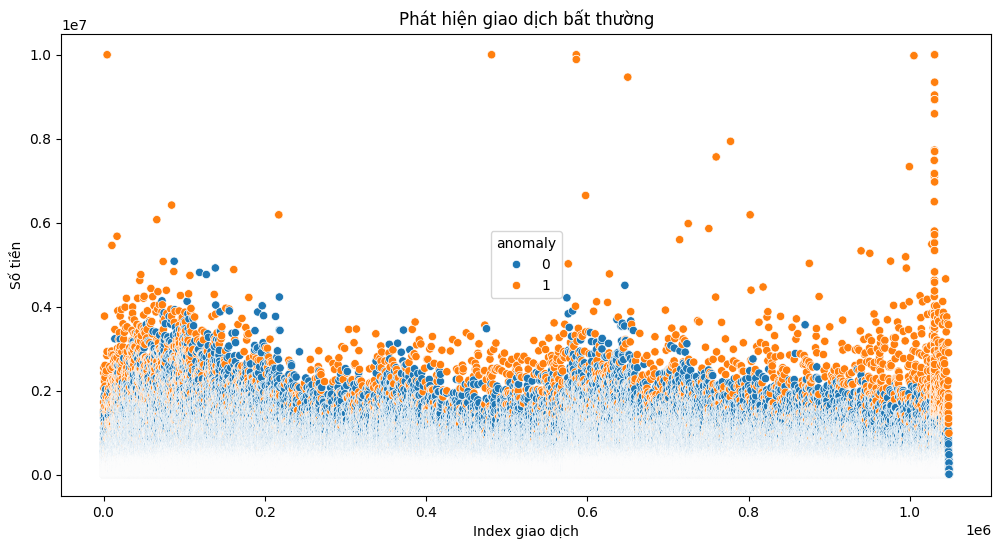

In [13]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    x=model_df.index,
    y=model_df['amount'],
    hue=model_df['anomaly']
)

plt.title('Phát hiện giao dịch bất thường')
plt.xlabel('Index giao dịch')
plt.ylabel('Số tiền')

plt.show()

In [14]:
if y_true is not None:
    print(classification_report(
        y_true,
        model_df['anomaly']
    ))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99   1047433
           1       0.01      0.19      0.02      1142

    accuracy                           0.98   1048575
   macro avg       0.50      0.58      0.50   1048575
weighted avg       1.00      0.98      0.99   1048575



In [15]:
model_df.to_csv(
    'ket_qua_bat_thuong.csv',
    index=False
)

print("Đã lưu file kết quả")

Đã lưu file kết quả


In [16]:
from google.colab import files

files.download('ket_qua_bat_thuong.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>